<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-10 </h1> </html>

# SID :- 2517680

<html> <h2 style="font-style:italic; color:blue;"> Simple AutoEncoders with Image Data </h2> </html>

Here is a simple autoencoder with just the dense layers.


Load the data and import the libraries.

In [1]:
# Your code to import matplotlib, pandas and numpy libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


_______________________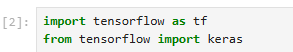

In [2]:
import tensorflow as tf
from tensorflow import keras

__________________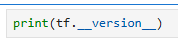

In [3]:
print(tf.__version__)

2.20.0


____________________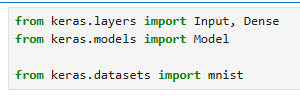

In [4]:
from keras.layers import Input, Dense
from keras.models import Model
from keras.datasets import mnist

In [5]:
# Your code to load MNIST data and store it in variables x_train, x_test. 
# Note -  we do not need labels as it's autoencoder.


(x_train, _), (x_test, _) = mnist.load_data()

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)



x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)


______________________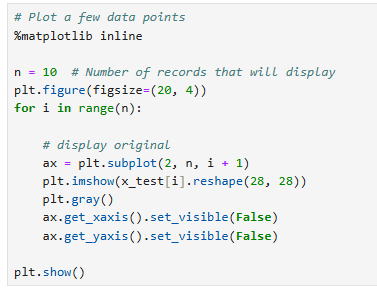

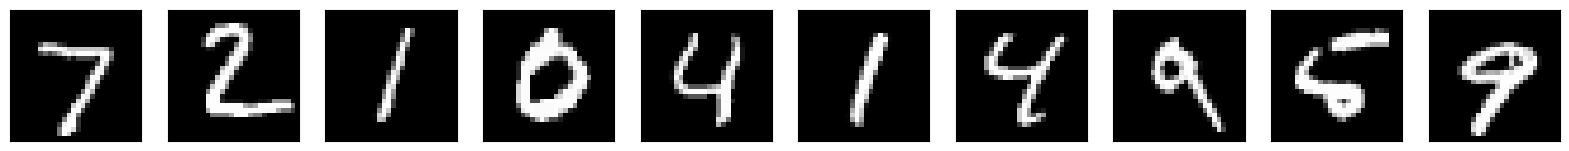

In [6]:
%matplotlib inline

n = 10
plt.figure(figsize=(20,4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)  

plt.show()

In [7]:
# Your code to
# normalise train data - Divided by 255


x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


# normalise test data - Divided by 255

#


<html> <h3 style="font-style:italic; color:blue;"> Basic AutoEncoder : </h3> </html>

Build a basic symmetric encoder-decoder network that recreates the image.  
This network could be used in dimensionaliry reduction or feature learning. 


________________________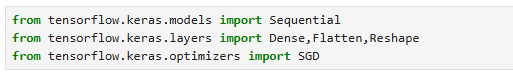

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.optimizers import SGD

In [9]:
encoder = Sequential()
encoder.add(Flatten(input_shape=[28,28]))

# Add as many layers in the Encoder network of your choice

encoder.add(Dense(400, activation="relu"))           
encoder.add(Dense(200, activation="relu"))           
encoder.add(Dense(100, activation="relu"))           
encoder.add(Dense(50,  activation="relu"))           
encoder.add(Dense(30,  activation="relu"))          

# The last TWO layers of the Encoder and Decoder must be matched (see the following decoder cell)

#
#


C:\Users\Madushan Pro\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:

decoder = Sequential()
decoder.add(Dense(50,  activation="relu", input_shape=[30]))   # mirrors bottleneck    ← first decoder layer
decoder.add(Dense(100, activation="relu"))                      # mirrors hidden layer 4
decoder.add(Dense(200, activation="relu"))                      # mirrors hidden layer 3
decoder.add(Dense(400, activation="relu"))                      # mirrors hidden layer 2
decoder.add(Dense(784, activation="sigmoid"))                   # output (pixel values in [0,1])
decoder.add(Reshape([28, 28]))                                  # back to image shape


C:\Users\Madushan Pro\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Your code to print your Encoder model

encoder.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │         1,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 420,880 (1.61 MB)

 Trainable params: 420,880 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Your OWN Encoder model should be printed here 
# Please do not copy the model below

In [12]:
# Your code to print the Decoder model

decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 50)             │         1,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 400)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │       314,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,634 (1.61 MB)

 Trainable params: 421,634 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Your OWN Decoder model should be printed here 
# Please do not copy the model below

____________________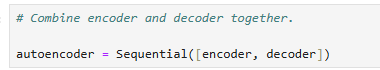

In [14]:
autoencoder = Sequential([encoder, decoder])

In [15]:
# Your code to print the Autoencoder model
autoencoder.compile(
    loss="binary_crossentropy",
    optimizer=SGD(learning_rate=1.0),
    metrics=["accuracy"]
)
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 30)             │       420,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28)         │       421,634 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 842,514 (3.21 MB)

 Trainable params: 842,514 (3.21 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Your OWN Autoencoder model should be printed here 

In [17]:
#SGD?

In [18]:
# Your code to compile the Autoencoder. 
# Use binary_crossenropy as loss and metrics as accuracy.

#


___________________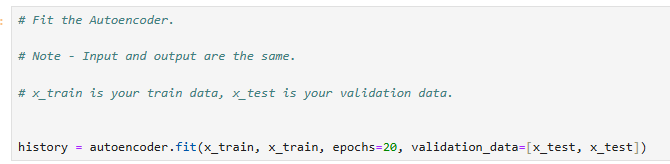

In [19]:
history = autoencoder.fit(x_train, x_train, epochs=20, validation_data=(x_test, x_test))


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.0832 - loss: 0.2567 - val_accuracy: 0.1066 - val_loss: 0.2193
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.1436 - loss: 0.1966 - val_accuracy: 0.1676 - val_loss: 0.1758
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.1850 - loss: 0.1625 - val_accuracy: 0.1983 - val_loss: 0.1519
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.2043 - loss: 0.1497 - val_accuracy: 0.2092 - val_loss: 0.1444
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.2174 - loss: 0.1419 - val_accuracy: 0.2227 - val_loss: 0.1366
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.2273 - loss: 0.1366 - val_accuracy: 0.2316 - val_loss: 0.1319
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.2339 - loss: 0.1328 - val_accuracy: 0.2316 - val_loss: 0.1317
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.2394 - loss: 0

____________________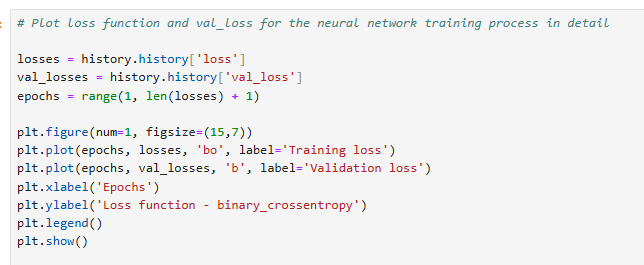

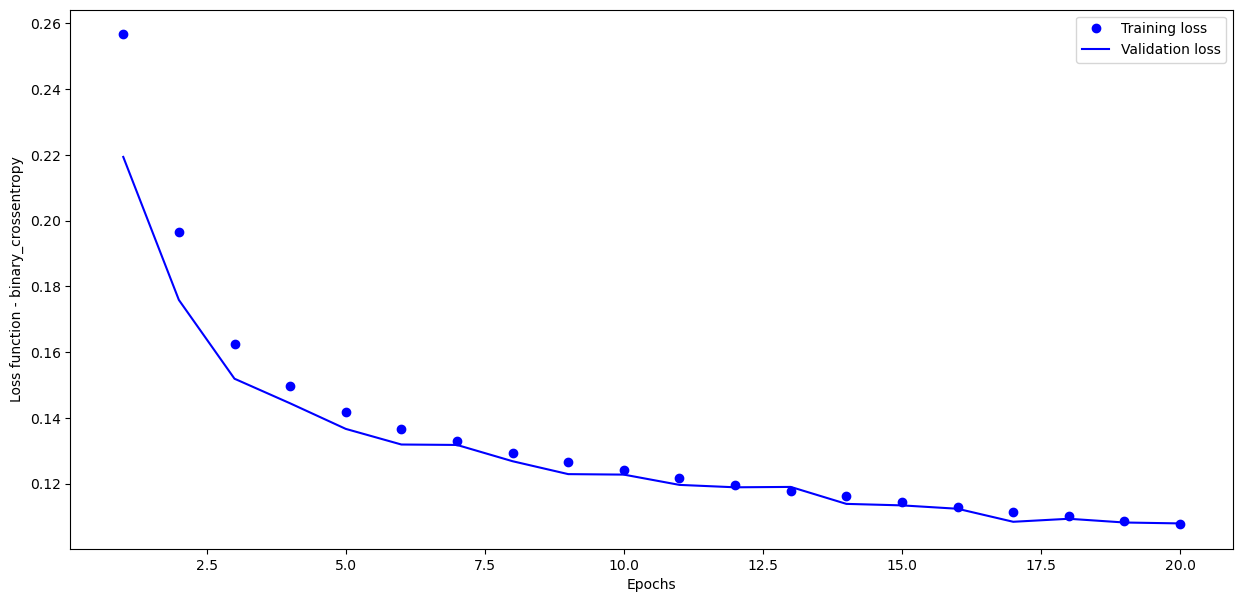

In [20]:
# Plot loss function and val_loss for the neural network training process in detail

losses = history.history['loss']
val_losses = history.history['val_loss']
epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss function - binary_crossentropy')
plt.legend()
plt.show()

___________________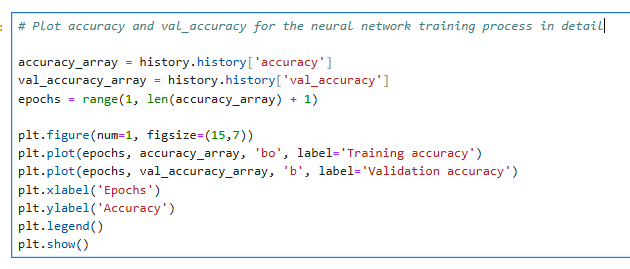

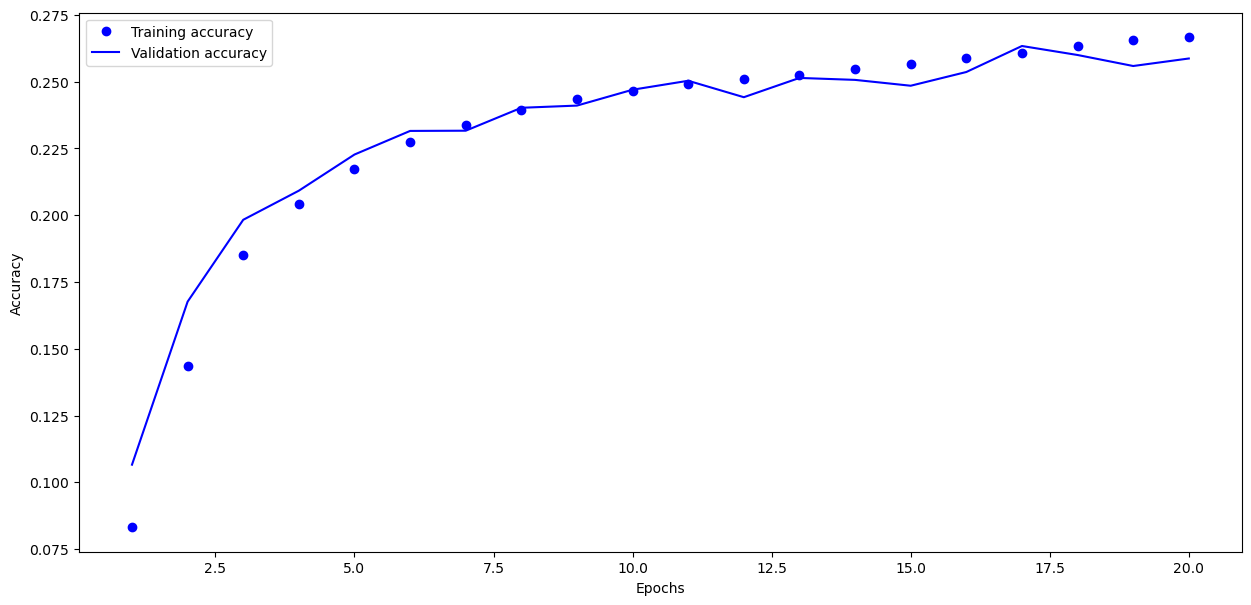

In [21]:
# Plot accuracy and val_accuracy for the neural network training process in detail

accuracy_array = history.history['accuracy']
val_accuracy_array = history.history['val_accuracy']
epochs = range(1, len(accuracy_array) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, accuracy_array, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_array, 'b', label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

_______________________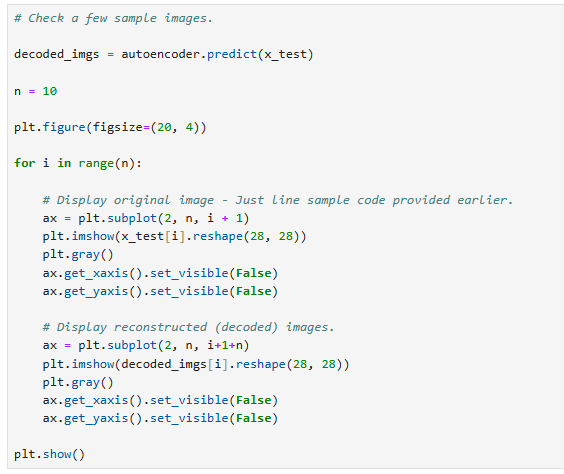

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


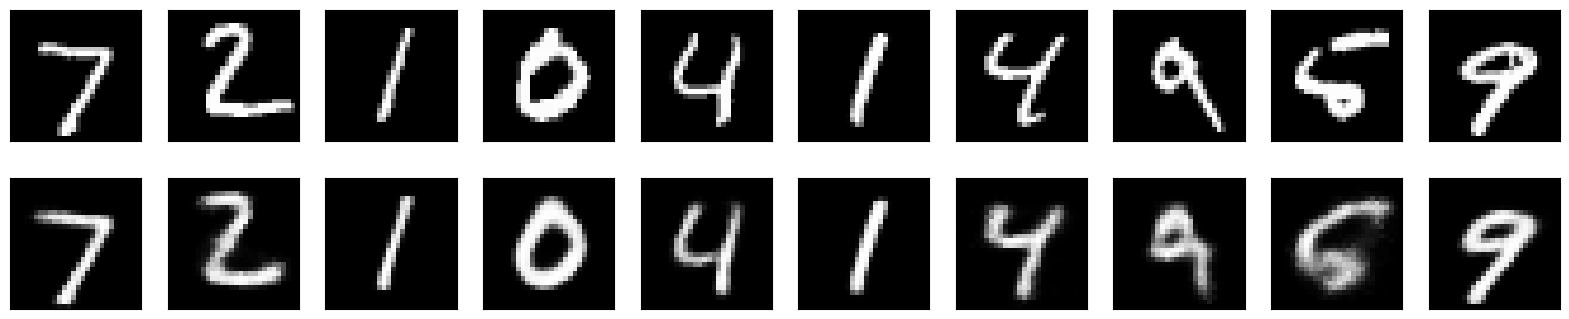

In [22]:
# Check a few sample images.

decoded_imgs = autoencoder.predict(x_test)

n = 10

plt.figure(figsize=(20, 4))

for i in range(n):

    # Display original image - Just line sample code provided earlier.
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed (decoded) images.
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

<html> <h3 style="font-style:italic; color:blue;"> AutoEncoders for Denoising Images : </h3> </html>

Use the same digit data set. Add Gaussian noise to it to train an autoencoder that removes noise. Test the noisy samples. 


______________________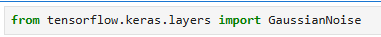

In [23]:
from tensorflow.keras.layers import GaussianNoise

In [ ]:
#GaussianNoise?

___________________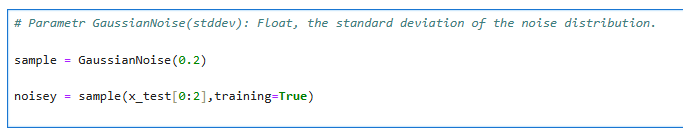

In [24]:
sample = GaussianNoise(0.2)
noisey = sample(x_test[0:2],training=True)

In [ ]:
# Plot the original and noisy images

_______________________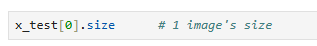

In [25]:
x_test[0].size

784

____________________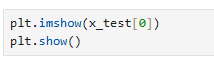

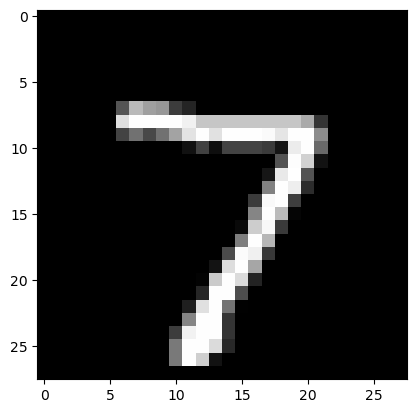

In [26]:
plt.imshow(x_test[0])
plt.show()

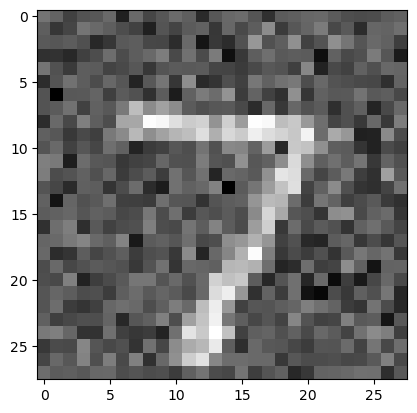

In [27]:
plt.imshow(noisey[0])
plt.show()

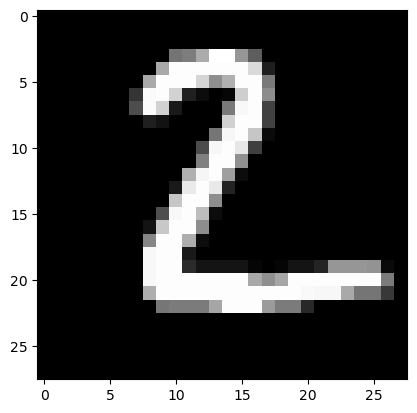

In [28]:
plt.imshow(x_test[1])
plt.show()

_________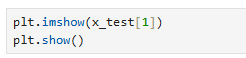

______________________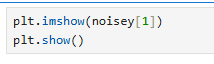

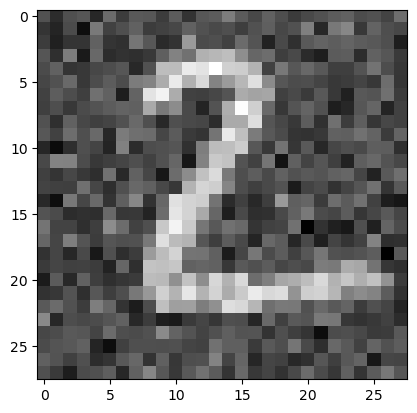

In [29]:
plt.imshow(noisey[1])
plt.show()

<html> <h4 style="font-style:italic; color:blue;"> Create a noise removal autoencoder and train it </h4> </html>

- Again similar to above it is a symmetric dense network. 
- Gaussian noise is added at the input so that the network sees noisy images and is able to map it to the clean outputs.


### Input - Images with noise
### Labels - Clean images.


In [30]:
# Encoder

encoder = Sequential()
encoder.add(Flatten(input_shape=[28,28]))
encoder.add(GaussianNoise(0.2)) # We are adding noise to make input as noisy images

# Add layers of Encoder network. You could use the same number of layers as you created earlier

encoder.add(Dense(400, activation="relu"))
encoder.add(Dense(200, activation="relu"))
encoder.add(Dense(100, activation="relu"))
encoder.add(Dense(50,  activation="relu"))
encoder.add(Dense(30,  activation="relu"))

print(encoder.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_1                │ (None, 784)            │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 30)             │         1,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 420,880 (1.61 MB)

 Trainable params: 420,880 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Your OWN Encoder model should be printed here 
# Please do not copy the model below

In [31]:
decoder = Sequential()
decoder.add(Dense(50,  activation="relu", input_shape=[30]))

# Add layers of the Decoder network. You could use the same number of layers as you created earlier
# Reember - Encoder and Decoder must be symmetric

decoder.add(Dense(100, activation="relu"))
decoder.add(Dense(200, activation="relu"))
decoder.add(Dense(400, activation="relu"))

decoder.add(Dense(28 * 28, activation="sigmoid"))
decoder.add(Reshape([28, 28]))

print(decoder.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 50)             │         1,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 400)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 784)            │       314,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,634 (1.61 MB)

 Trainable params: 421,634 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Your OWN Decoder model should be printed here 
# Please do not copy the model below

_________________________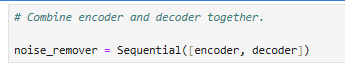

In [32]:
noise_remover = Sequential([encoder,decoder]) 
noise_remover.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 30)             │       420,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 28, 28)         │       421,634 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 842,514 (3.21 MB)

 Trainable params: 842,514 (3.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Your code to print the Autoencoder model

#

In [ ]:
# Your OWN Autoencoder model should be printed here 

In [33]:
# Your code to compile the 'noise_remover' model with the same parameters as earlier

# noise_remover.compile( ................  )
noise_remover.compile(
    loss="binary_crossentropy",
    optimizer=SGD(learning_rate=1.0),
    metrics=["accuracy"]
)

In [34]:
# Your code to fit 'noise_remover' model with the same parameters as earlier

history_2 = noise_remover.fit(x_train, x_train, epochs=20, validation_data=(x_test, x_test))


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.0731 - loss: 0.2612 - val_accuracy: 0.1052 - val_loss: 0.2302
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.1248 - loss: 0.2137 - val_accuracy: 0.1408 - val_loss: 0.2082
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.1617 - loss: 0.1827 - val_accuracy: 0.1811 - val_loss: 0.1671
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - accuracy: 0.1905 - loss: 0.1617 - val_accuracy: 0.1983 - val_loss: 0.1488
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.2069 - loss: 0.1487 - val_accuracy: 0.2101 - val_loss: 0.1436
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step - accuracy: 0.2174 - loss: 0.1421 - val_accuracy: 0.2283 - val_loss: 0.1363
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.2239 - loss: 0.1381 - val_accuracy: 0.2224 - val_loss: 0.1348
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.2283 - loss

In [ ]:
# Hint: Use (copy and modify) the code from the cells above

___________________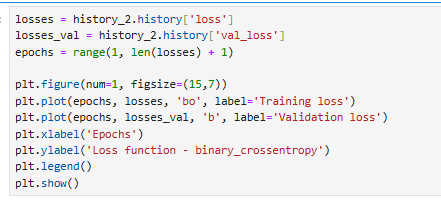

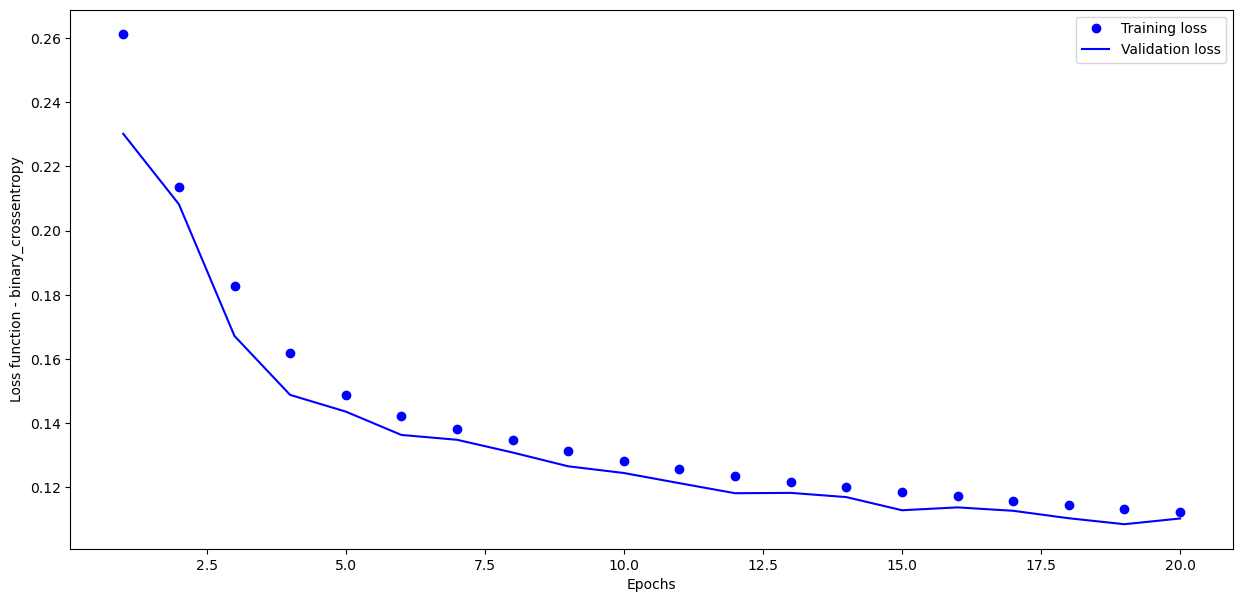

In [35]:
losses = history_2.history['loss']
losses_val = history_2.history['val_loss']
epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, losses, 'bo', label='Training loss')
plt.plot(epochs, losses_val, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss function - binary_crossentropy')
plt.legend()
plt.show()

___________________________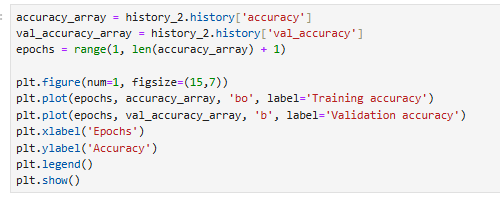

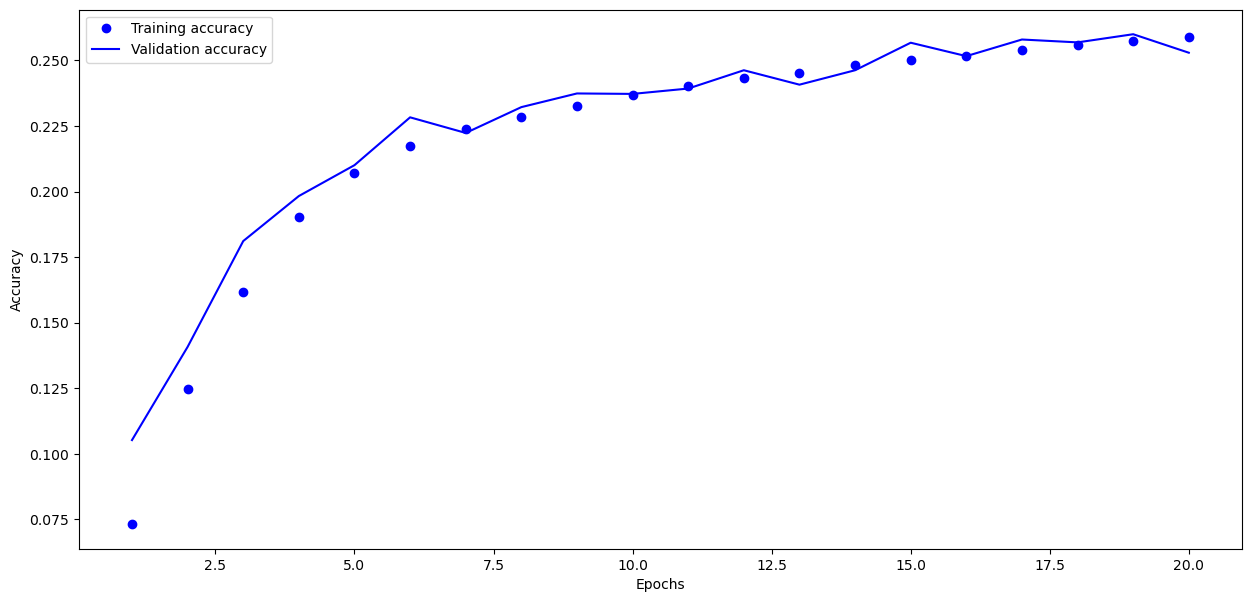

In [36]:
accuracy_array = history_2.history['accuracy']
val_accuracy_array = history_2.history['val_accuracy']
epochs = range(1, len(accuracy_array) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, accuracy_array, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_array, 'b', label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

______________________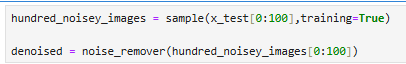

In [37]:
hundred_noisey_images = sample(x_test[0:100],training=True)
denoised = noise_remover(hundred_noisey_images[0:100])

______________________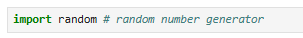

In [38]:
import random

_______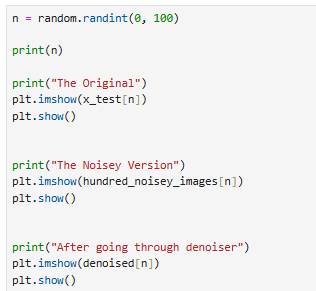

68
The Original


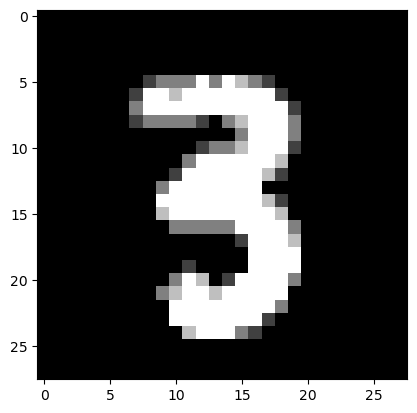

The Noisey Version


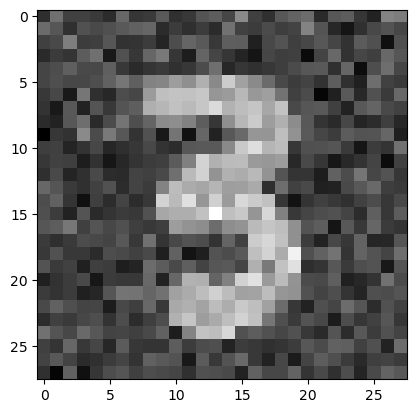

After going through denoiser


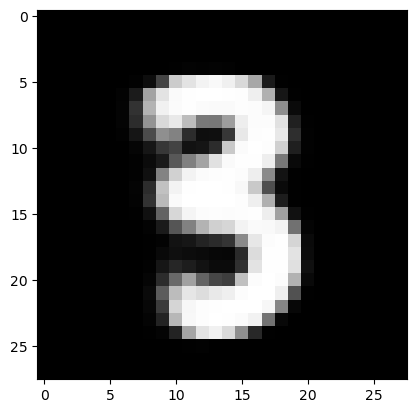

In [39]:
n = random.randint(0, 100)

print(n)

print("The Original")
plt.imshow(x_test[n])
plt.show()


print("The Noisey Version")
plt.imshow(hundred_noisey_images[n])
plt.show()


print("After going through denoiser")
plt.imshow(denoised[n])
plt.show()

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

 - Put the Encoder, Decoder and Basic Autoencoder models using summary() in your lab logbook.

Ensure that no code or other information is added to the logbook and that only required information is present. Marks will not be awarded if anything else is found in the logbook or instructions are not clearly followed.

NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB OR ONEDRIVE.